In [35]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Lets Load the Boston Housing Dataset.

In [36]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [37]:
df.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [38]:
# Lets check the discreption of the dataset:

print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [39]:
boston.data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [40]:
print(boston.target)

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64


In [41]:
print(boston.feature_names)

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


### Preprocessing The Dataset

In [42]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [43]:
# adds the target as a new column:

df['Price'] = boston.target

In [44]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
 14  Price    506 non-null    float64 
dtypes: category(2), float64(13)
memory usage: 53.0 KB


In [46]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000,50.000000


In [47]:
##Check the missing values

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
Price      0
dtype: int64

### Exploratory Data Analysis


In [48]:
# Correlation

df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536,-0.468536


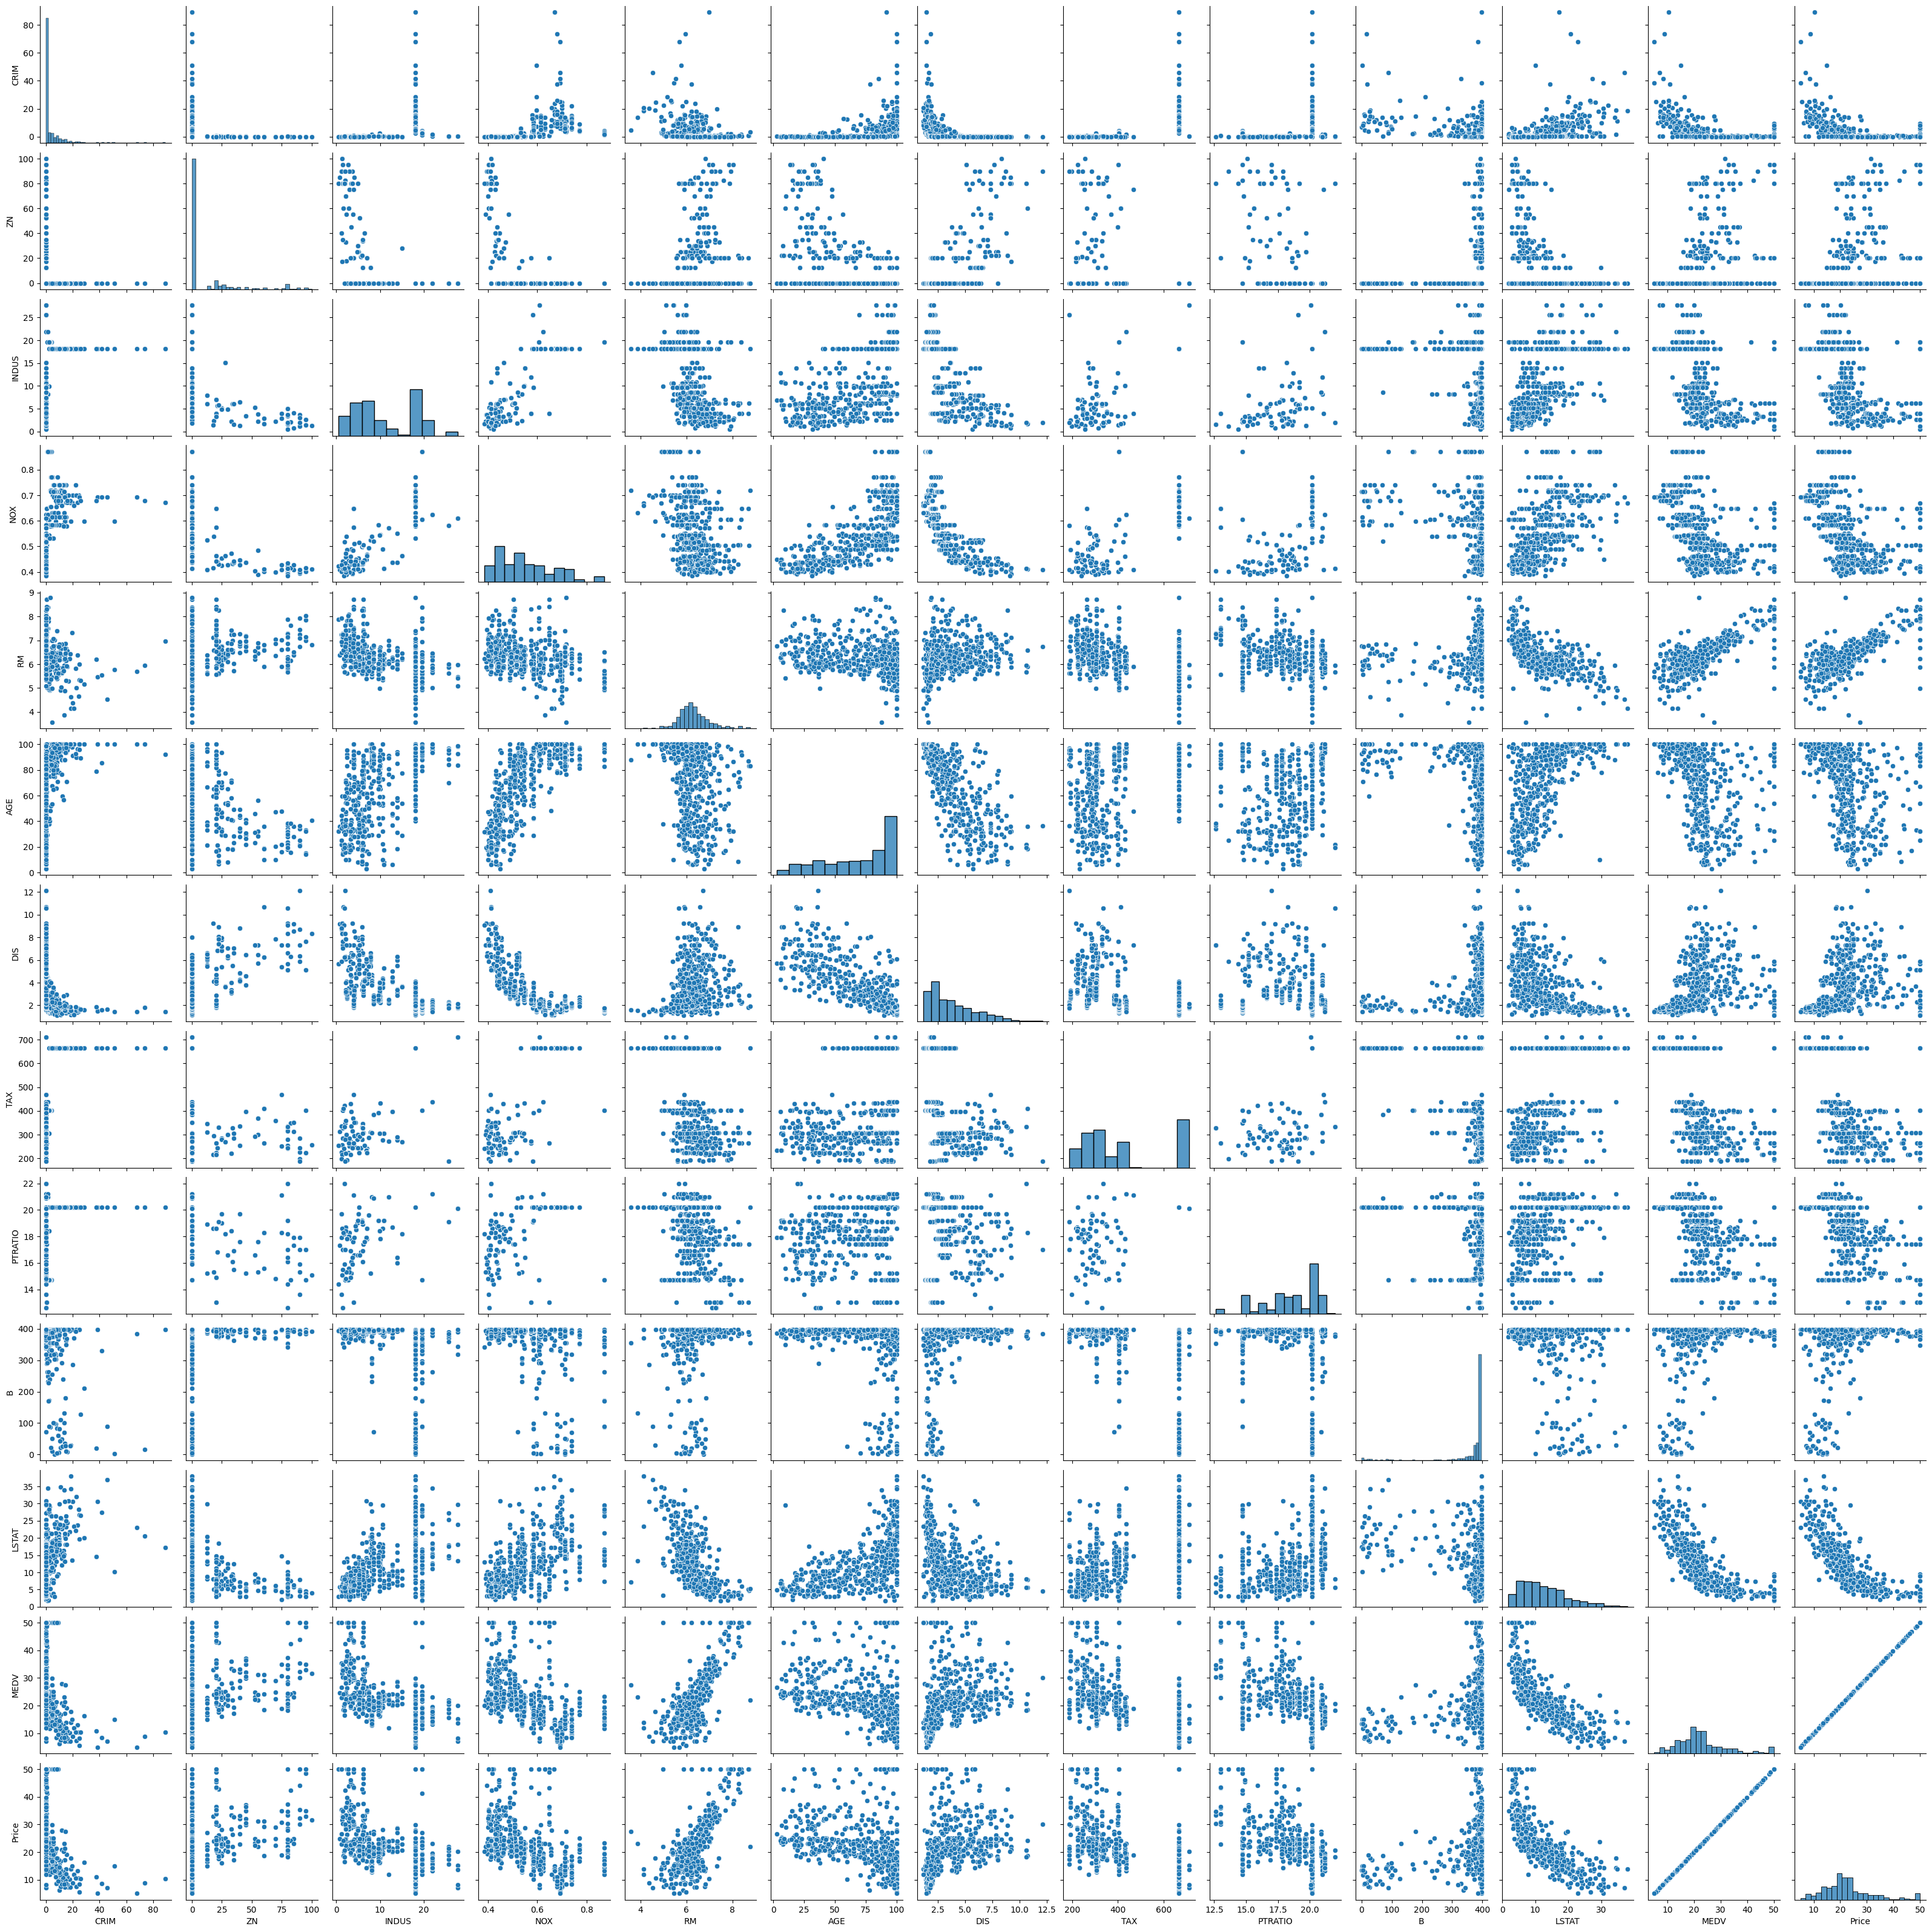

In [49]:
sns.pairplot(df)

<Axes: xlabel='CRIM', ylabel='Price'>

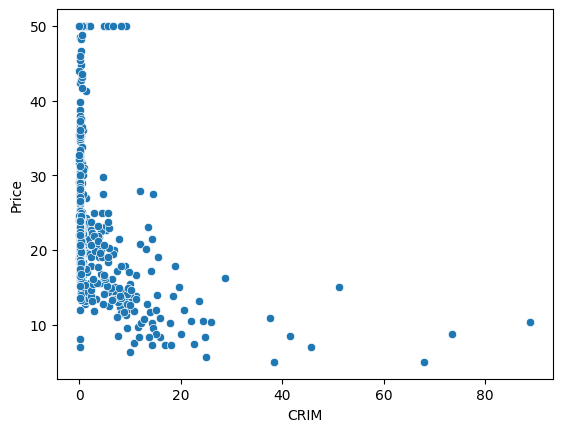

In [50]:
sns.scatterplot(x='CRIM', y='Price', data=df)

<Axes: xlabel='RM', ylabel='Price'>

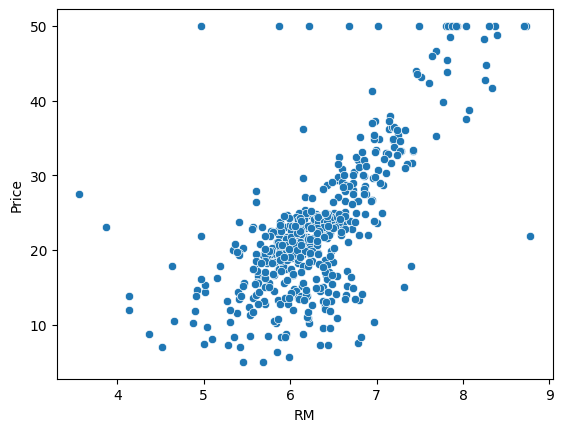

In [51]:
sns.scatterplot(df, x='RM', y='Price')

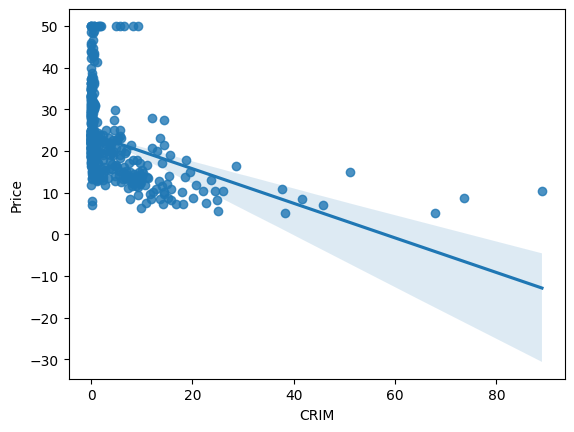

In [52]:
# Regression Plot
# Shows the relationship between CRIM (crime rate) and Price.
# Each dot represents one house.
# The blue line is the best-fit regression line.
# A downward line indicates a negative relationship:
# as crime rate increases, house prices tend to decrease.

sns.regplot(data=df, x="CRIM", y="Price")
plt.show()


<Axes: xlabel='TAX', ylabel='Price'>

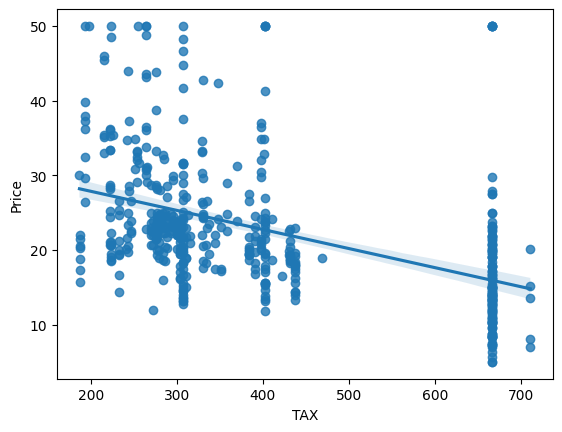

In [53]:
sns.regplot(df, x='TAX', y='Price')

<Axes: xlabel='AGE', ylabel='Price'>

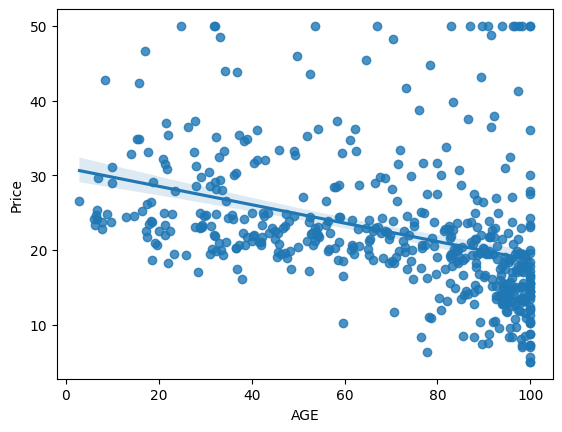

In [54]:
sns.regplot(df, x='AGE', y='Price')

In [55]:
## Indepandent and Depandent features

X = df.drop('Price', axis=1)   # Input Feature
y = df['Price']                ## Target Feature

In [56]:
X.head()
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [57]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

In [58]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
58,0.15445,25.0,5.13,0,0.453,6.145,29.2,7.8148,8,284.0,19.7,390.68,6.86,23.3
410,51.13580,0.0,18.10,0,0.597,5.757,100.0,1.4130,24,666.0,20.2,2.60,10.11,15.0
481,5.70818,0.0,18.10,0,0.532,6.750,74.9,3.3317,24,666.0,20.2,393.07,7.74,23.7
69,0.12816,12.5,6.07,0,0.409,5.885,33.0,6.4980,4,345.0,18.9,396.90,8.79,20.9
41,0.12744,0.0,6.91,0,0.448,6.770,2.9,5.7209,3,233.0,17.9,385.41,4.84,26.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,22.05110,0.0,18.10,0,0.740,5.818,92.4,1.8662,24,666.0,20.2,391.45,22.11,10.5
165,2.92400,0.0,19.58,0,0.605,6.101,93.0,2.2834,5,403.0,14.7,240.16,9.81,25.0
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
219,0.11425,0.0,13.89,1,0.550,6.373,92.4,3.3633,5,276.0,16.4,393.74,10.50,23.0


In [59]:
## Standardize the dataset

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# List of numerical columns
# These columns contain continuous numerical values and need feature scaling.
num_cols = [
    "CRIM", "ZN", "INDUS", "NOX", "RM",
    "AGE", "DIS", "TAX", "PTRATIO", "B", "LSTAT"
]

# List of categorical columns
# These columns contain categories and need to be converted into numerical format.
cat_cols = ["CHAS", "RAD"]

# Create a ColumnTransformer
# - Apply StandardScaler to numerical columns.
# - Apply OneHotEncoder to categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Fit the preprocessor on the training data and transform it.
# The scaler learns the mean and standard deviation only from the training data.
# The encoder learns the unique categories only from the training data.
X_train = preprocessor.fit_transform(X_train)

# Transform the test data using the same preprocessing learned from the training data.
# Do NOT use fit_transform() on the test data to avoid data leakage.
X_test = preprocessor.transform(X_test)

In [60]:
X_train

array([[-0.45098379,  0.59163708, -0.84258861, ...,  0.        ,
         0.        ,  1.        ],
       [ 7.93012362, -0.50215615,  1.06054133, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.46202474, -0.50215615,  1.06054133, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.45261131,  0.04474047, -0.44053957, ...,  0.        ,
         0.        ,  0.        ],
       [-0.45759249, -0.50215615,  0.44279445, ...,  0.        ,
         0.        ,  0.        ],
       [-0.42648556, -0.50215615, -0.51243885, ...,  0.        ,
         0.        ,  0.        ]], shape=(354, 22))

### Model trainning

In [61]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
## Print the coefficient and the intercept

print(regression.coef_)

[-0.70135413  1.02229501 -0.46529376 -1.97687321  2.19759629 -0.11352138
 -2.99438156 -1.03579798 -1.86259353  0.65136487 -3.25197517 -1.68587984
  1.68587984 -2.33228461 -0.97803011  3.60537041  1.64612636 -0.51193752
 -0.47526206 -2.99830295  0.79158306  1.25273742]


### Prediction with test Data

In [63]:
reg_pred = regression.predict(X_test)
reg_pred

array([21.91350426, 32.81882433, 11.55454739, 16.27597481, 17.84627774,
       31.83895488, 25.33000613, 15.78394002, 22.07675391, -3.8072457 ,
       28.27255712, 15.43076535,  5.91731287,  5.78917439, 25.96841127,
       34.79987486, 26.19213815, 19.17312553, 23.66714663, 14.75859114,
       39.23929275, 11.12103396, 38.99654705, 25.87599401, 38.98574759,
       25.34886477, 21.55746922, 19.19772891, 18.50786474, 18.49513292,
       24.17442363, 23.49201037, 28.82325212, 23.2693742 ,  0.87154043,
       26.63841899, 27.23518945, 12.43762321, 39.21425664, 32.82448288,
       24.2482102 ,  6.79733215, 17.97852318, 20.9440736 , 31.54480314,
        7.61183056, 12.64653633, 30.35705123, 22.92091742, 35.74708066,
       13.07136331, 20.6592684 , 18.70732606,  7.07354258,  5.67338393,
       40.22805899, 25.23074922, 24.90709838, 23.02033235,  8.14023715,
       24.92315298,  9.51046953, 32.8732927 , 11.47642118, 28.44101305,
       17.24040086,  4.08621191, 30.45208484, 19.38019811, 18.75

<Axes: xlabel='Price'>

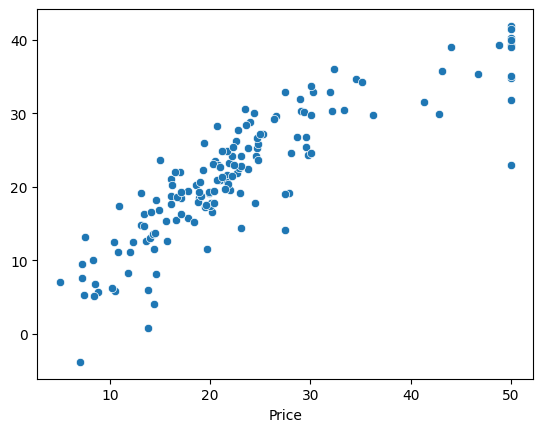

In [64]:
 ## Scatter Plot of Prediction 
sns.scatterplot(x=y_test, y=reg_pred)

R^2 and adjusted R^2 are two important metrics used to evaluate the performance of regression models.

In [65]:
from sklearn.metrics import r2_score

score = r2_score(y_test, reg_pred)
print(score)

0.7227331374136625


## New Data Prediction

In [75]:
boston.data.iloc[0]

CRIM       0.00632
ZN            18.0
INDUS         2.31
CHAS             0
NOX          0.538
RM           6.575
AGE           65.2
DIS           4.09
RAD              1
TAX          296.0
PTRATIO       15.3
B            396.9
LSTAT         4.98
Name: 0, dtype: object

In [76]:
boston.data.iloc[0].values.reshape(1, -1)

array([[np.float64(0.00632), np.float64(18.0), np.float64(2.31), '0',
        np.float64(0.538), np.float64(6.575), np.float64(65.2),
        np.float64(4.09), '1', np.float64(296.0), np.float64(15.3),
        np.float64(396.9), np.float64(4.98)]], dtype=object)

In [78]:
sample = boston.data.iloc[[0]]

sample_scaled = preprocessor.transform(sample)

prediction = regression.predict(sample_scaled)

print(prediction)

[28.82325212]


### Pickling the model file for deployment in future.

In [ ]:
import pickle

pickle.dump(regression, open('regression_model.pkl', 'wb'))

pickle_model = pickle.load(open('regression_model.pkl', 'rb'))

## Predicting the price of the first house in the dataset using the pickled model.

pickle_model.predict(sample_scaled)

array([28.82325212])